# Uber Data Analytics Project
This notebook simulates the entire data engineering and analytics pipeline locally inside Google Colab.
It loads the raw NYC/Uber trip records, performs data transformations to create a **Star Schema** (Fact and Dimension tables), loads them into a local SQL database (SQLite), executes the analytics SQL query, and plots the final insights.

### Steps Included:
1. **Extract**: Fetch raw CSV data from a public raw GitHub URL.
2. **Preprocess**: Format data types and clean duplicates.
3. **Transform**: Build 7 Dimension tables and 1 Fact table (Star Schema).
4. **Load (Local Database)**: Load tables into a local SQLite database.
5. **SQL Analytics**: Execute the consolidated analytics query.
6. **Data Visualization**: Generate dashboard charts using matplotlib & seaborn.

## Step 1: Ingest Data (Extract)

In [ ]:
import io
import pandas as pd
import requests
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Set plots style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
# Fetching NYC TLC trip records from public raw GitHub repository to avoid GCS 403 Forbidden errors
url = 'https://raw.githubusercontent.com/darshilparmar/uber-etl-pipeline-data-engineering-project/main/data/uber_data.csv'
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

print(f"Raw dataset loaded successfully! Shape: {df.shape}")
df.head()

Raw dataset loaded successfully! Shape: (100000, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


## Step 2: Clean & Preprocess Data

In [ ]:
# Convert datetime columns to datetime data types
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Remove duplicates and reset the index to assign a unique trip_id
df = df.drop_duplicates().reset_index(drop=True)
df['trip_id'] = df.index

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (100000, 20)


## Step 3: Data Transformation (Creating Star Schema)

In [ ]:
# 1. Datetime Dimension Table
datetime_dim = df[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].drop_duplicates().reset_index(drop=True)
datetime_dim['datetime_id'] = datetime_dim.index
datetime_dim['pick_hour'] = datetime_dim['tpep_pickup_datetime'].dt.hour
datetime_dim['pick_day'] = datetime_dim['tpep_pickup_datetime'].dt.day
datetime_dim['pick_month'] = datetime_dim['tpep_pickup_datetime'].dt.month
datetime_dim['pick_year'] = datetime_dim['tpep_pickup_datetime'].dt.year
datetime_dim['pick_weekday'] = datetime_dim['tpep_pickup_datetime'].dt.weekday

datetime_dim['drop_hour'] = datetime_dim['tpep_dropoff_datetime'].dt.hour
datetime_dim['drop_day'] = datetime_dim['tpep_dropoff_datetime'].dt.day
datetime_dim['drop_month'] = datetime_dim['tpep_dropoff_datetime'].dt.month
datetime_dim['drop_year'] = datetime_dim['tpep_dropoff_datetime'].dt.year
datetime_dim['drop_weekday'] = datetime_dim['tpep_dropoff_datetime'].dt.weekday

datetime_dim = datetime_dim[[
    'datetime_id', 'tpep_pickup_datetime', 'pick_hour', 'pick_day', 'pick_month', 'pick_year', 'pick_weekday',
    'tpep_dropoff_datetime', 'drop_hour', 'drop_day', 'drop_month', 'drop_year', 'drop_weekday'
]]

# 2. Passenger Count Dimension Table
passenger_count_dim = df[['passenger_count']].drop_duplicates().reset_index(drop=True)
passenger_count_dim['passenger_count_id'] = passenger_count_dim.index
passenger_count_dim = passenger_count_dim[['passenger_count_id', 'passenger_count']]

# 3. Trip Distance Dimension Table
trip_distance_dim = df[['trip_distance']].drop_duplicates().reset_index(drop=True)
trip_distance_dim['trip_distance_id'] = trip_distance_dim.index
trip_distance_dim = trip_distance_dim[['trip_distance_id', 'trip_distance']]

# 4. Rate Code Dimension Table
rate_code_type = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride"
}
rate_code_dim = df[['RatecodeID']].drop_duplicates().reset_index(drop=True)
rate_code_dim['rate_code_id'] = rate_code_dim.index
rate_code_dim['rate_code_name'] = rate_code_dim['RatecodeID'].map(rate_code_type)
rate_code_dim = rate_code_dim[['rate_code_id', 'RatecodeID', 'rate_code_name']]

# 5. Pickup Location Dimension Table
pickup_location_dim = df[['pickup_longitude', 'pickup_latitude']].drop_duplicates().reset_index(drop=True)
pickup_location_dim['pickup_location_id'] = pickup_location_dim.index
pickup_location_dim = pickup_location_dim[['pickup_location_id', 'pickup_longitude', 'pickup_latitude']]

# 6. Dropoff Location Dimension Table
dropoff_location_dim = df[['dropoff_longitude', 'dropoff_latitude']].drop_duplicates().reset_index(drop=True)
dropoff_location_dim['dropoff_location_id'] = dropoff_location_dim.index
dropoff_location_dim = dropoff_location_dim[['dropoff_location_id', 'dropoff_longitude', 'dropoff_latitude']]

# 7. Payment Type Dimension Table
payment_type_name = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}
payment_type_dim = df[['payment_type']].drop_duplicates().reset_index(drop=True)
payment_type_dim['payment_type_id'] = payment_type_dim.index
payment_type_dim['payment_type_name'] = payment_type_dim['payment_type'].map(payment_type_name)
payment_type_dim = payment_type_dim[['payment_type_id', 'payment_type', 'payment_type_name']]

# 8. Fact Table
fact_table = df.merge(passenger_count_dim, on='passenger_count') \
               .merge(trip_distance_dim, on='trip_distance') \
               .merge(rate_code_dim, on='RatecodeID') \
               .merge(pickup_location_dim, on=['pickup_longitude', 'pickup_latitude']) \
               .merge(dropoff_location_dim, on=['dropoff_longitude', 'dropoff_latitude']) \
               .merge(datetime_dim, on=['tpep_pickup_datetime', 'tpep_dropoff_datetime']) \
               .merge(payment_type_dim, on='payment_type') \
               [[
                   'trip_id', 'VendorID', 'datetime_id', 'passenger_count_id',
                   'trip_distance_id', 'rate_code_id', 'store_and_fwd_flag', 'pickup_location_id',
                   'dropoff_location_id', 'payment_type_id', 'fare_amount', 'extra', 'mta_tax',
                   'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount'
               ]]

print("Star Schema tables created successfully!")
print(f"Fact Table shape: {fact_table.shape}")

Star Schema tables created successfully!
Fact Table shape: (100000, 17)


## Step 4: Load Modeled Tables to Local SQL Database

In [ ]:
# Connect to an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Write dataframes to SQL tables
datetime_dim.to_sql('datetime_dim', conn, index=False, if_exists='replace')
passenger_count_dim.to_sql('passenger_count_dim', conn, index=False, if_exists='replace')
trip_distance_dim.to_sql('trip_distance_dim', conn, index=False, if_exists='replace')
rate_code_dim.to_sql('rate_code_dim', conn, index=False, if_exists='replace')
pickup_location_dim.to_sql('pickup_location_dim', conn, index=False, if_exists='replace')
dropoff_location_dim.to_sql('dropoff_location_dim', conn, index=False, if_exists='replace')
payment_type_dim.to_sql('payment_type_dim', conn, index=False, if_exists='replace')
fact_table.to_sql('fact_table', conn, index=False, if_exists='replace')

print("Data loaded into SQL database tables successfully!")

Data loaded into SQL database tables successfully!


## Step 5: SQL Analytics Query
We join all the tables inside the database to produce the consolidated analytics report.

In [ ]:
query = """
SELECT
  f.trip_id,
  f.VendorID,
  d.tpep_pickup_datetime,
  d.tpep_dropoff_datetime,
  p.passenger_count,
  t.trip_distance,
  r.rate_code_name,
  pick.pickup_latitude,
  pick.pickup_longitude,
  dr.dropoff_latitude,
  dr.dropoff_longitude,
  pay.payment_type_name,
  f.fare_amount,
  f.extra,
  f.mta_tax,
  f.tip_amount,
  f.tolls_amount,
  f.improvement_surcharge,
  f.total_amount
FROM
  fact_table f
  JOIN datetime_dim d ON f.datetime_id = d.datetime_id
  JOIN passenger_count_dim p ON f.passenger_count_id = p.passenger_count_id
  JOIN trip_distance_dim t ON f.trip_distance_id = t.trip_distance_id
  JOIN rate_code_dim r ON f.rate_code_id = r.rate_code_id
  JOIN pickup_location_dim pick ON f.pickup_location_id = pick.pickup_location_id
  JOIN dropoff_location_dim dr ON f.dropoff_location_id = dr.dropoff_location_id
  JOIN payment_type_dim pay ON f.payment_type_id = pay.payment_type_id
"""

# Run the SQL query and load the results into a pandas dataframe
df_analytics = pd.read_sql_query(query, conn)
print(f"Analytics report generated! Shape: {df_analytics.shape}")
df_analytics.head()

Analytics report generated! Shape: (100000, 19)


,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,rate_code_name,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,payment_type_name,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,Standard rate,40.765152,-73.976746,40.746128,-74.004265,Credit card,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,Standard rate,40.767925,-73.983482,40.733166,-74.005943,Credit card,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,Standard rate,40.644810,-73.782021,40.675770,-73.974541,Credit card,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,Standard rate,40.769814,-73.863419,40.757767,-73.969650,Credit card,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,Newark,40.792183,-73.971741,40.695053,-74.177170,Credit card,98.0,0.0,0.0,0.00,15.50,0.3,113.80


## Step 6: Data Visualization (Colab Dashboard)

/tmp/ipykernel_1129/825557157.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_hour', data=df_analytics, palette='viridis')


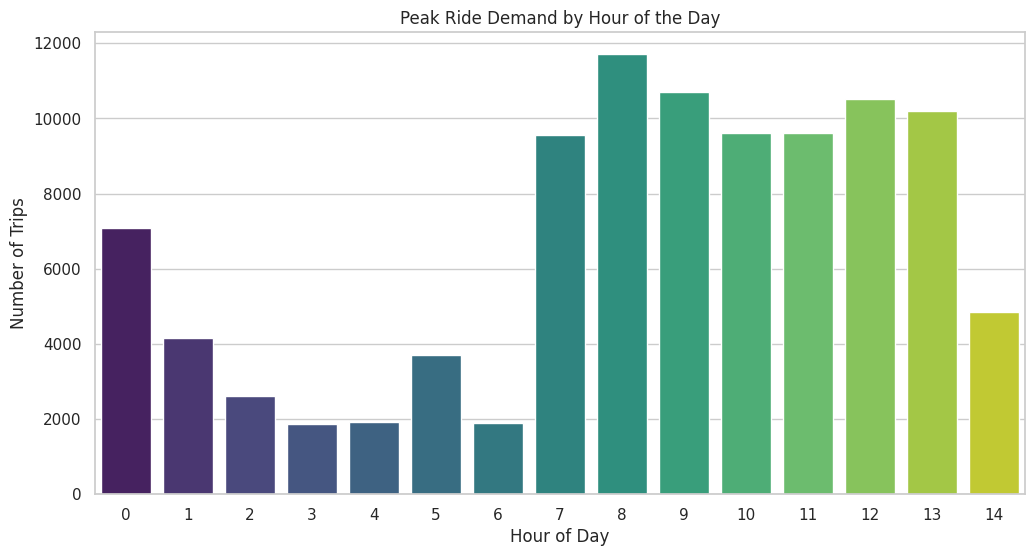

In [ ]:
# Plot 1: Peak Pickup Hours
df_analytics['pickup_hour'] = pd.to_datetime(df_analytics['tpep_pickup_datetime']).dt.hour
sns.countplot(x='pickup_hour', data=df_analytics, palette='viridis')
plt.title('Peak Ride Demand by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

/tmp/ipykernel_1129/3987297973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='payment_type_name', y='fare_amount', data=avg_fare_payment, palette='magma')


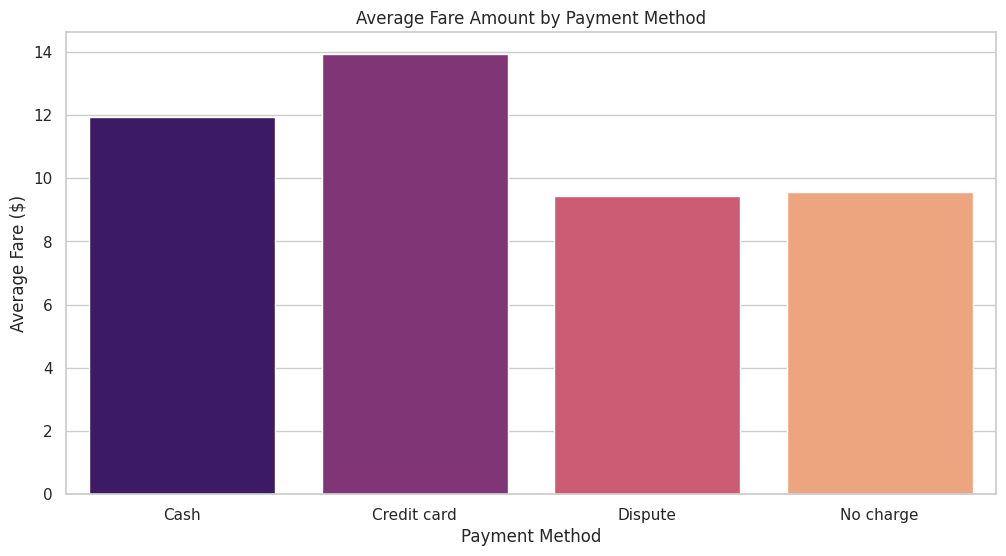

In [ ]:
# Plot 2: Average Fare by Payment Type
avg_fare_payment = df_analytics.groupby('payment_type_name')['fare_amount'].mean().reset_index()
sns.barplot(x='payment_type_name', y='fare_amount', data=avg_fare_payment, palette='magma')
plt.title('Average Fare Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Fare ($)')
plt.show()

/tmp/ipykernel_1129/1070648863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tip_amount', y='rate_code_name', data=avg_tip_rate, palette='coolwarm')


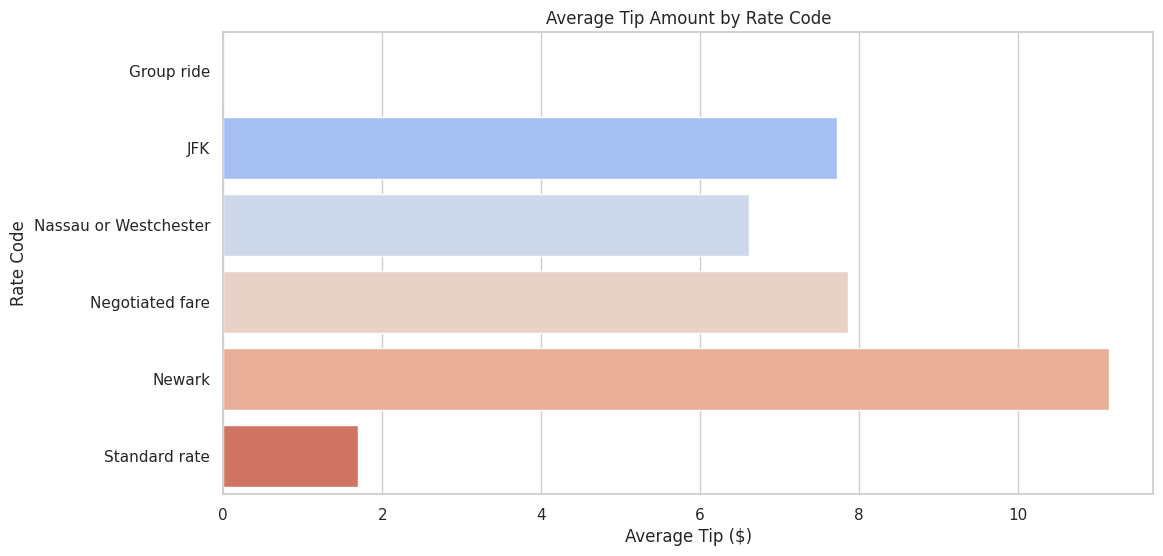

In [ ]:
# Plot 3: Average Tip by Rate Code
avg_tip_rate = df_analytics.groupby('rate_code_name')['tip_amount'].mean().reset_index()
sns.barplot(x='tip_amount', y='rate_code_name', data=avg_tip_rate, palette='coolwarm')
plt.title('Average Tip Amount by Rate Code')
plt.xlabel('Average Tip ($)')
plt.ylabel('Rate Code')
plt.show()